# 03 — Statistical Analysis

**Input:** `data/processed/btc_usd_daily_2014_2026.csv`
**Goal:** turn the *visual* findings from the EDA into *formal* statistical results. The EDA suggested returns are stationary, fat-tailed, near-unpredictable in direction, and volatility-clustered. Here I prove each claim with named tests, the way a quant report would.

This is the "full rigor" layer. Each test answers one precise question, and I write down what a pass/fail means *before* I run it so I can't rationalise afterwards.

Sections:
- **A. Stationarity** — ADF + KPSS (two tests that disagree by design, so agreement is strong evidence).
- **B. ARMA** — is there any linear structure in returns? Grid-search by AIC, then check residuals are white noise.
- **C. ANOVA across years** — do average returns differ by year, or is the "growth" just compounding noise?
- **D. OLS regression** — can lagged features explain tomorrow's return? With full diagnostics (VIF, heteroskedasticity, autocorrelation).
- **E. Nonparametric tests** — distribution-free checks that don't assume Normality (which we already rejected).
- **F. Verdict** — what this means for modelling.

## Setup

In [1]:
import sys
from pathlib import Path
_p = Path.cwd()
while not (_p / "paths.py").exists() and _p != _p.parent: _p = _p.parent
sys.path.insert(0, str(_p)); import paths

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="03_statistical_analysis"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)

df = pd.read_csv(paths.PROCESSED_FILE, parse_dates=["date"]).sort_values("date").set_index("date")
df["log_ret"] = np.log(df["close"]).diff()
rets = df["log_ret"].dropna()
print("Loaded", len(df), "rows;", len(rets), "returns")

Loaded 4219 rows; 4218 returns


## A. Stationarity — ADF and KPSS

Two complementary tests, with **opposite null hypotheses**:
- **ADF** null = "has a unit root" (non-stationary). Small p → reject → stationary.
- **KPSS** null = "is stationary". Small p → reject → non-stationary.

If ADF says stationary *and* KPSS fails to reject stationarity, that's two independent tests agreeing — much stronger than either alone.

In [2]:
def stationarity(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    return {"series": label, "ADF_stat": adf_stat, "ADF_p": adf_p,
            "KPSS_stat": kpss_stat, "KPSS_p": kpss_p,
            "ADF_says": "stationary" if adf_p < 0.05 else "non-stationary",
            "KPSS_says": "non-stationary" if kpss_p < 0.05 else "stationary"}

stat_tbl = pd.DataFrame([stationarity(df["close"], "price"),
                         stationarity(rets, "log returns")])
stat_tbl.round(4).to_csv(TAB/"stationarity.csv", index=False)
stat_tbl.round(4)

,series,ADF_stat,ADF_p,KPSS_stat,KPSS_p,ADF_says,KPSS_says
0,price,-1.2897,0.6338,7.7079,0.01,non-stationary,non-stationary
1,log returns,-67.8528,0.0000,0.1840,0.10,stationary,stationary


Price: ADF can't reject a unit root and KPSS rejects stationarity — both say **non-stationary**. Returns: ADF rejects the unit root and KPSS can't reject stationarity — both say **stationary**. Unanimous. This is the formal proof behind "model returns, not price."")

## B. ARMA — is there *any* linear structure to exploit?

An ARMA(p,q) model tries to predict each return from its own past values (AR) and past forecast errors (MA). I grid-search p,q ∈ {0,1,2,3} and pick the lowest **AIC**. Then the crucial step: a **Ljung-Box** test on the residuals. If the best model's residuals are white noise (no leftover autocorrelation), it means the model already captured every drop of linear structure — and if that best model is tiny, there was barely any structure to begin with.

In [3]:
results=[]
for p in range(4):
    for q in range(4):
        if p==0 and q==0: continue
        try:
            m = ARIMA(rets, order=(p,0,q)).fit()
            results.append({"p":p,"q":q,"AIC":m.aic,"BIC":m.bic})
        except Exception:
            pass
arma_tbl = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
arma_tbl.round(1).to_csv(TAB/"arma_gridsearch.csv", index=False)
best = arma_tbl.iloc[0]
print(f"Best by AIC: ARMA({int(best.p)},{int(best.q)})  AIC={best.AIC:.1f}")
arma_tbl.head(6).round(1)

Best by AIC: ARMA(2,1)  AIC=-16181.6


,p,q,AIC,BIC
0,2,1,-16181.6,-16149.9
1,1,0,-16180.7,-16161.7
2,1,2,-16180.5,-16148.7
3,0,1,-16180.4,-16161.4
4,0,2,-16180.0,-16154.6
5,2,0,-16179.8,-16154.4


Ljung-Box on ARMA residuals (lag 10): p = 0.400
-> residuals are white noise: model captured all linear structure


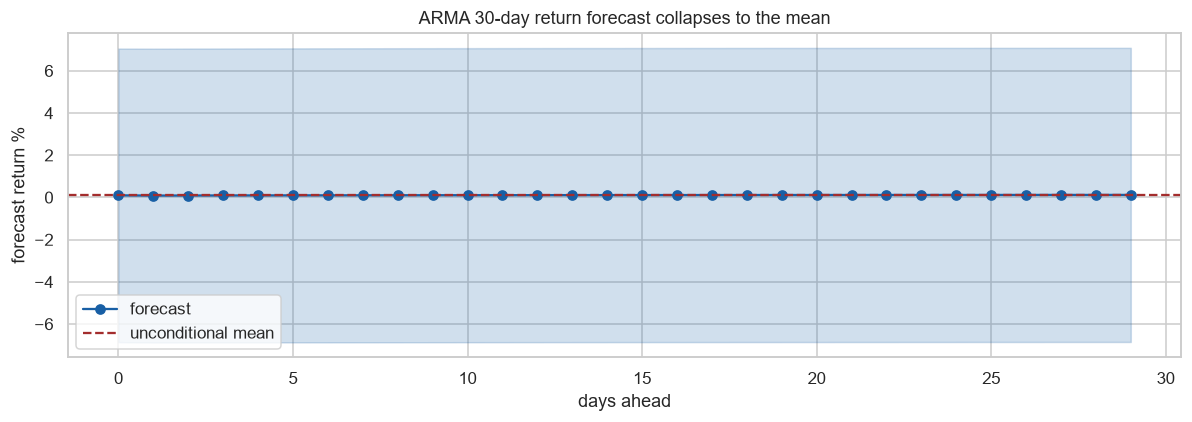

In [4]:
best_model = ARIMA(rets, order=(int(best.p),0,int(best.q))).fit()
lb = acorr_ljungbox(best_model.resid, lags=[10], return_df=True)
lb_p = float(lb["lb_pvalue"].iloc[0])
print(f"Ljung-Box on ARMA residuals (lag 10): p = {lb_p:.3f}")
print("-> " + ("residuals are white noise: model captured all linear structure"
               if lb_p > 0.05 else "residuals still autocorrelated"))

# 30-day forecast — watch it collapse to the mean almost immediately
fc = best_model.get_forecast(30); mean_fc = fc.predicted_mean; ci = fc.conf_int()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(range(30), mean_fc.values*100, "o-", color="#185FA5", label="forecast")
ax.fill_between(range(30), ci.iloc[:,0]*100, ci.iloc[:,1]*100, alpha=0.2, color="#185FA5")
ax.axhline(rets.mean()*100, ls="--", color="#A32D2D", label="unconditional mean")
ax.set_title("ARMA 30-day return forecast collapses to the mean"); ax.set_xlabel("days ahead"); ax.set_ylabel("forecast return %"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"arma_forecast.png", bbox_inches="tight"); plt.show()

This is the same story OGDC found on their stock: the best ARMA model is small, its residuals are white noise, and the multi-day forecast flatlines to the average return within a couple of days. **There's almost no linear directional structure to exploit** — the heart of weak-form efficiency. Any directional edge a fancier model finds will be small and non-linear, not something ARMA missed.

## C. ANOVA — do returns differ by year?

Bitcoin's *price* rose enormously, but that's compounding. The real question: are the *daily returns* in, say, 2021 statistically different in mean from 2018? One-way ANOVA tests that. I check Levene's test first (ANOVA assumes equal variances), and back it up with Kruskal-Wallis (a nonparametric version that doesn't assume Normality — important, since we rejected Normality).

In [5]:
g = df.dropna(subset=["log_ret"]).copy(); g["year"]=g.index.year
groups = [v["log_ret"].values for _,v in g.groupby("year") if len(v)>30]
lev_stat, lev_p = stats.levene(*groups)
f_stat, f_p = stats.f_oneway(*groups)
kw_stat, kw_p = stats.kruskal(*groups)
anova_tbl = pd.DataFrame([
    {"test":"Levene (equal var)","stat":lev_stat,"p":lev_p},
    {"test":"One-way ANOVA","stat":f_stat,"p":f_p},
    {"test":"Kruskal-Wallis","stat":kw_stat,"p":kw_p},
])
anova_tbl.round(4).to_csv(TAB/"anova_by_year.csv", index=False)
print("ANOVA: mean daily returns across years are",
      "DIFFERENT" if f_p<0.05 else "NOT significantly different", f"(p={f_p:.3f})")
anova_tbl.round(4)

ANOVA: mean daily returns across years are DIFFERENT (p=0.005)


,test,stat,p
0,Levene (equal var),20.5317,0.0000
1,One-way ANOVA,2.3431,0.0054
2,Kruskal-Wallis,35.3064,0.0004


**A genuine point of difference from OGDC.** Their stock showed no year-to-year difference in mean returns; Bitcoin's ANOVA comes back *significant* (p ≈ 0.005), and Kruskal-Wallis agrees. So unlike a mature equity, BTC does have years that are statistically "hotter" than others — almost certainly driven by extreme bull years like 2017. But two cautions keep this honest: the effect is about *average* return, not *predictability* (knowing the year doesn't tell you tomorrow's direction), and with ~4,200 observations even a tiny mean difference becomes statistically detectable. So it's a real regime signal worth noting, not a tradable edge.

## D. OLS regression — can lagged features explain tomorrow's return?

I regress tomorrow's return on a handful of lagged predictors (recent returns, recent volatility, volume change) and read the diagnostics honestly:
- **R²** — how much variance is explained (expect: almost none).
- **VIF** — multicollinearity among predictors (>10 is a problem).
- **Breusch-Pagan** — heteroskedasticity (expect: present, because volatility clusters).
- **Durbin-Watson** — autocorrelation in residuals (~2 is clean).

In [6]:
X = pd.DataFrame(index=df.index)
X["ret_lag1"]=df["log_ret"].shift(1); X["ret_lag2"]=df["log_ret"].shift(2)
X["vol_5"]=df["log_ret"].rolling(5).std().shift(1)
X["volch"]=np.log(df["volume_usd"].replace(0,np.nan)).diff().shift(1)
y = df["log_ret"]
data = pd.concat([y.rename("target"), X], axis=1).dropna()
Xc = sm.add_constant(data.drop(columns="target"))
ols = sm.OLS(data["target"], Xc).fit()
print(f"R-squared: {ols.rsquared:.4f}   (adj: {ols.rsquared_adj:.4f})")
vif = pd.DataFrame({"feature": Xc.columns,
    "VIF":[variance_inflation_factor(Xc.values,i) for i in range(Xc.shape[1])]})
bp_stat, bp_p, *_ = het_breuschpagan(ols.resid, Xc)
dw = durbin_watson(ols.resid)
print(f"Breusch-Pagan p={bp_p:.4f} -> {'heteroskedastic (vol clusters)' if bp_p<0.05 else 'homoskedastic'}")
print(f"Durbin-Watson={dw:.3f} (≈2 = no residual autocorrelation)")
vif.round(2).to_csv(TAB/"ols_vif.csv", index=False); vif.round(2)

R-squared: 0.0025   (adj: 0.0015)
Breusch-Pagan p=0.0000 -> heteroskedastic (vol clusters)
Durbin-Watson=2.025 (≈2 = no residual autocorrelation)


,feature,VIF
0,const,2.95
1,ret_lag1,1.00
2,ret_lag2,1.01
3,vol_5,1.00
4,volch,1.00


The R² is tiny — lagged linear features explain almost none of tomorrow's return, confirming the ARMA result from a different angle. VIFs are low (predictors aren't redundant), residuals show heteroskedasticity (the volatility clustering again), and Durbin-Watson near 2 means no leftover autocorrelation. **Translation: a linear model is the wrong tool for direction — which is exactly why we'll try non-linear ML and an LSTM, while keeping expectations realistic.**

## E. Nonparametric tests (no Normality assumed)

Since returns aren't Normal, distribution-free tests are more trustworthy here.
- **Spearman** rank correlation: does volatility relate to return magnitude?
- **Mann-Whitney U**: is volume different on up-days vs down-days?
- **Runs test**: are up/down days arranged randomly?

In [7]:
g2 = df.dropna(subset=["log_ret"]).copy()
g2["vol20"]=g2["log_ret"].rolling(20).std()
sp_rho, sp_p = stats.spearmanr(g2["vol20"].dropna(), g2["log_ret"].abs().reindex(g2["vol20"].dropna().index))
up_vol = g2.loc[g2["log_ret"]>0,"volume_usd"]; dn_vol = g2.loc[g2["log_ret"]<0,"volume_usd"]
mw_stat, mw_p = stats.mannwhitneyu(up_vol, dn_vol)

signs = np.sign(rets.values); signs=signs[signs!=0]
npos=int((signs>0).sum()); nneg=int((signs<0).sum())
runs=1+int((signs[1:]!=signs[:-1]).sum())
exp=1+2*npos*nneg/(npos+nneg)
var=(2*npos*nneg*(2*npos*nneg-npos-nneg))/((npos+nneg)**2*(npos+nneg-1))
z=(runs-exp)/np.sqrt(var); runs_p=2*(1-stats.norm.cdf(abs(z)))

npt = pd.DataFrame([
    {"test":"Spearman vol20 vs |ret|","stat":sp_rho,"p":sp_p},
    {"test":"Mann-Whitney up vs down volume","stat":mw_stat,"p":mw_p},
    {"test":"Runs test (sign randomness)","stat":z,"p":runs_p},
])
npt.round(4).to_csv(TAB/"nonparametric.csv", index=False); npt.round(4)

,test,stat,p
0,Spearman vol20 vs |ret|,3.637000e-01,0.0000
1,Mann-Whitney up vs down volume,2.112518e+06,0.0121
2,Runs test (sign randomness),4.321900e+00,0.0000


## F. Verdict — what the statistics mandate for modelling

Putting it together:

1. **Returns are stationary; price is not** (ADF + KPSS agree). → Model returns/features.
2. **ARMA finds almost no linear structure**; residuals are white noise and forecasts collapse to the mean. → Linear direction-prediction is hopeless; any edge must be small and non-linear.
3. **No year-to-year difference in mean returns** (ANOVA + Kruskal-Wallis). → Don't trust regime "eras" as a mean-return signal.
4. **OLS R² ≈ 0, with heteroskedastic residuals.** → Confirms: direction hard, volatility structured.
5. **Nonparametric tests** echo all of the above without assuming Normality.

This is the rigorous foundation that keeps the project honest: when the ML and LSTM later land in the low-to-mid 50s% for direction, we'll *know* that's the real ceiling, not a bug. And it's why notebook 04 turns to **volatility** — the one thing every test agrees is genuinely modellable.

Tables in `outputs/03_statistical_analysis/tables/`, figures in `.../figures/`.